<a id="05"></a>

## 05 — Envelope Analysis
### Mục 1.3 (minh chứng ở mục 0.2) — Giải điều chế Envelope

**Mục đích**: minh chứng vì sao cần Envelope Analysis — tín hiệu thô/phổ
thô thường **không lộ rõ** BPFO/BPFI/BSF vì bị điều biên bởi cộng hưởng cơ
khí; phổ Envelope (sau khi giải điều chế) mới bộc lộ rõ các đỉnh này.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle
from common.features_dynamic import hybrid_envelope

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [ ]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = True

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False,12000.0
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False,12000.0
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False,12000.0
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False,12000.0
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False,12000.0


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [ ]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn dải bandpass

**Việc quan trọng nhất của notebook này**: `BAND_HZ` bên dưới là giá trị
**ví dụ**, cần chỉnh lại dựa trên quan sát thực tế ở notebook 03 (vùng tần
số có biên độ nổi bật nhất) kết hợp tài liệu kỹ thuật SKF 6205, theo đúng
quyết định ở mục 0.4 của đề cương — không dùng phương pháp dò tự động
(Kurtogram/Spectral Kurtosis).

In [ ]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
LOAD_HP = 0
FS = cfg.SCOPE["sampling_rate_hz"]
BAND_HZ = (2300, 3800)
LP_CUTOFF_HZ = 500
FREQ_MAX_PLOT = 500

fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=LOAD_HP, diameter_mils=DIAMETER_MILS)
x = io_utils.load_de_signal(Path(fp))
rpm = cfg.NOMINAL_RPM_BY_LOAD[LOAD_HP]
print(f"File: {fp}")
print(f"RPM danh định: {rpm}")

File: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\021\@6\234_0.mat
RPM danh định: 1797


## Phổ Envelope (Square-Law) — đánh dấu BPFO/BPFI/BSF/FTF lý thuyết

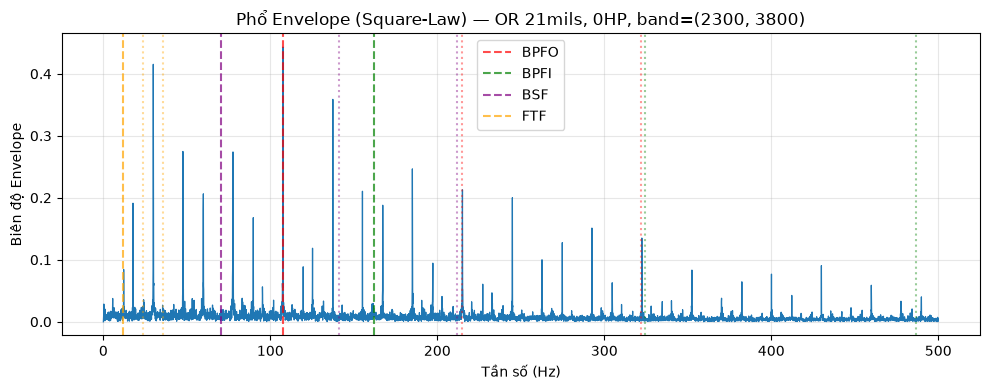

In [ ]:
envelope = dsp.square_law_envelope(x, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=FS)
fault_freqs = cfg.bearing_fault_frequencies(rpm)

fig, ax = plt.subplots(figsize=(10, 4))
mask = freqs <= FREQ_MAX_PLOT
ax.plot(freqs[mask], mag[mask], linewidth=0.9)

colors = {"BPFO": "red", "BPFI": "green", "BSF": "purple", "FTF": "orange"}
for name, f in fault_freqs.items():
    if name == "f_rot" or f > FREQ_MAX_PLOT:
        continue
    ax.axvline(f, color=colors.get(name, "gray"), linestyle="--", alpha=0.7, label=name)
    for h in (2, 3):
        if f * h <= FREQ_MAX_PLOT:
            ax.axvline(f * h, color=colors.get(name, "gray"), linestyle=":", alpha=0.4)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_spectrum_square_law.png", dpi=150)
plt.show()

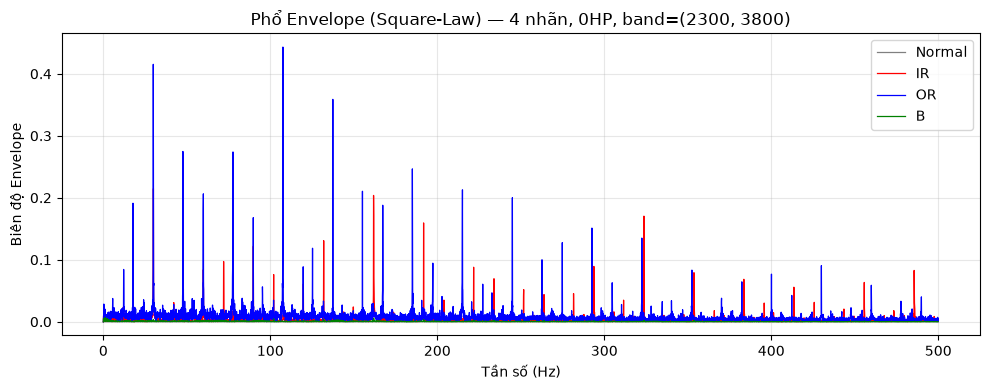

In [ ]:
label_colors = {"Normal": "gray", "IR": "red", "OR": "blue", "B": "green"}

fig, ax = plt.subplots(figsize=(10, 4))

for label, color in label_colors.items():
    if label == "Normal":
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    else:
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP,
                                diameter_mils=DIAMETER_MILS)

    x = io_utils.load_de_signal(Path(fp))
    envelope = dsp.square_law_envelope(x, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
    freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=FS)

    mask = freqs <= FREQ_MAX_PLOT
    ax.plot(freqs[mask], mag[mask], linewidth=0.9, color=color, label=label)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope (Square-Law) — 4 nhãn, {LOAD_HP}HP, band={BAND_HZ}")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_4_labels_overlay.png", dpi=150)
plt.show()

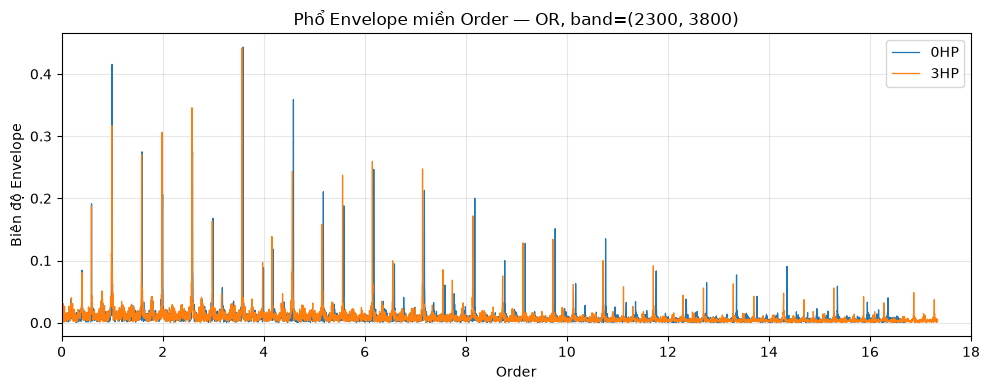

In [ ]:
ORDER_MAX_PLOT = 18

load_config = {
    0: {"color": "tab:blue",  "label": "0HP"},
    3: {"color": "tab:orange", "label": "3HP"},
}

fig, ax = plt.subplots(figsize=(10, 4))

for load_hp, lcfg in load_config.items():
    fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp,
                            diameter_mils=DIAMETER_MILS)
    x = io_utils.load_de_signal(Path(fp))
    rpm = cfg.NOMINAL_RPM_BY_LOAD[load_hp]

    envelope = dsp.square_law_envelope(x, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
    freqs, mag = dsp.compute_fft(envelope - envelope.mean(), fs=FS)

    orders = cfg.hz_to_order(freqs, rpm)
    mask = freqs <= FREQ_MAX_PLOT
    ax.plot(orders[mask], mag[mask], linewidth=0.9, color=lcfg["color"], label=lcfg["label"])

ax.set_xlabel("Order")
ax.set_ylabel("Biên độ Envelope")
ax.set_title(f"Phổ Envelope miền Order — {FAULT_LABEL}, band={BAND_HZ}")
ax.set_xlim(0, ORDER_MAX_PLOT)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_order_0hp_vs_3hp.png", dpi=150)
plt.show()

## So sánh 3 phương pháp DSP

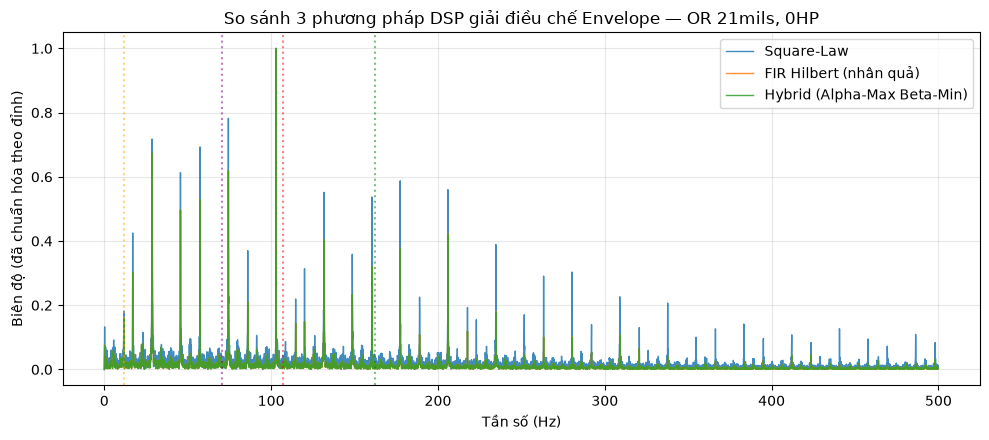

Tương quan Pearson hình dạng phổ (so với Square-Law):
  FIR Hilbert (nhân quả)        : r = 0.9537
  Hybrid (Alpha-Max Beta-Min)   : r = 0.9532


In [ ]:
# --- So sánh 3 phương pháp DSP trên CÙNG 1 trục, biên độ đã chuẩn hóa ---
# CẢ BA nhánh đều chạy NHÂN QUẢ và dùng chung bậc lọc + lp_cutoff nên so
# sánh mới công bằng. Bản Hilbert FFT + filtfilt (zero-phase) nằm ở
# dsp.hilbert_envelope() và CHỈ dùng làm đường tham chiếu offline.
envelope_sq = dsp.square_law_envelope(x, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
envelope_hb = dsp.hilbert_envelope_fir(x, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)
envelope_hy = hybrid_envelope(x, fs=FS, band=BAND_HZ)

methods = {"Square-Law": envelope_sq, "FIR Hilbert (nhân quả)": envelope_hb, "Hybrid (Alpha-Max Beta-Min)": envelope_hy}
method_colors = {"Square-Law": "tab:blue", "FIR Hilbert (nhân quả)": "tab:orange", "Hybrid (Alpha-Max Beta-Min)": "tab:green"}

spectra = {}
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, env in methods.items():
    freqs_m, mag_m = dsp.compute_fft(env - env.mean(), fs=FS)
    mask = freqs_m <= FREQ_MAX_PLOT
    mag_norm = mag_m[mask] / (mag_m[mask].max() + 1e-12)  # chuẩn hóa để so HÌNH DẠNG, không so biên độ tuyệt đối
    spectra[name] = (freqs_m[mask], mag_norm)
    ax.plot(freqs_m[mask], mag_norm, linewidth=1.0, color=method_colors[name], label=name, alpha=0.85)

for fname, f in fault_freqs.items():
    if fname == "f_rot" or f > FREQ_MAX_PLOT:
        continue
    ax.axvline(f, color=colors.get(fname, "gray"), linestyle=":", alpha=0.5)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ (đã chuẩn hóa theo đỉnh)")
ax.set_title(f"So sánh 3 phương pháp DSP giải điều chế Envelope — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_3_methods_overlay.png", dpi=150)
plt.show()

# Định lượng độ tương đồng HÌNH DẠNG phổ (hợp lệ dùng Pearson ở đây vì cùng lưới tần số,
# không phải window thô lệch pha như cảnh báo ở notebook 06)
from scipy.stats import pearsonr

_, ref_mag = spectra["Square-Law"]
print("Tương quan Pearson hình dạng phổ (so với Square-Law):")
for name in ("FIR Hilbert (nhân quả)", "Hybrid (Alpha-Max Beta-Min)"):
    _, mag_other = spectra[name]
    r, _ = pearsonr(ref_mag, mag_other)
    print(f"  {name:30s}: r = {r:.4f}")

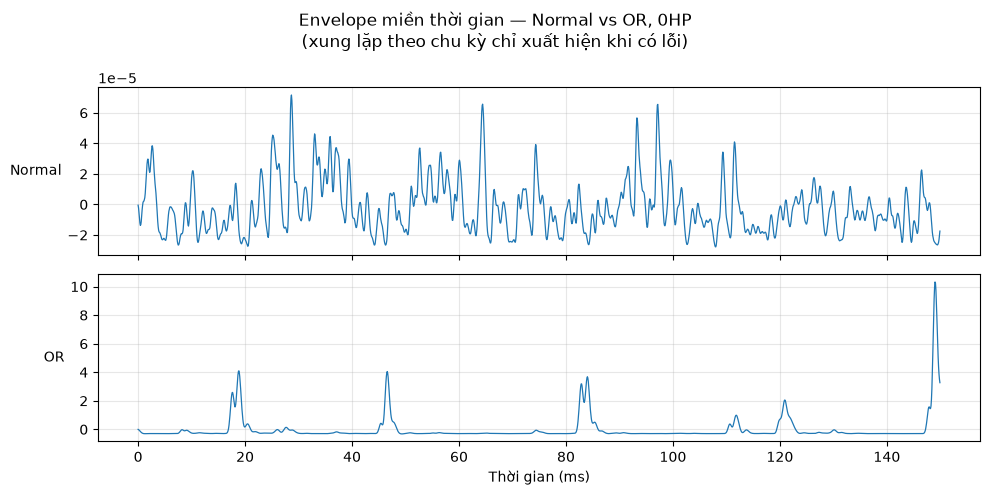

In [ ]:
# --- BỔ SUNG: Envelope miền THỜI GIAN — làm rõ quá trình giải điều chế, không chỉ xem phổ ---
COMPARE_LABELS_TIME = ["Normal", FAULT_LABEL]
N_SECONDS_ENV = 0.15

signals_env_time = {}
for label in COMPARE_LABELS_TIME:
    if label == "Normal":
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    else:
        fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP, diameter_mils=DIAMETER_MILS)
    x_l = io_utils.load_de_signal(Path(fp))
    signals_env_time[label] = dsp.square_law_envelope(x_l, fs=FS, band=BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)

fig, axes = plt.subplots(len(COMPARE_LABELS_TIME), 1, figsize=(10, 2.5 * len(COMPARE_LABELS_TIME)), sharex=True)
n_samples_env = int(N_SECONDS_ENV * FS)
t_ms_env = np.arange(n_samples_env) / FS * 1000

for ax, (label, env) in zip(axes, signals_env_time.items()):
    ax.plot(t_ms_env, env[:n_samples_env], linewidth=0.9, color="tab:blue")
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(f"Envelope miền thời gian — Normal vs {FAULT_LABEL}, {LOAD_HP}HP\n"
             f"(xung lặp theo chu kỳ chỉ xuất hiện khi có lỗi)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_time_domain_normal_vs_fault.png", dpi=150)
plt.show()

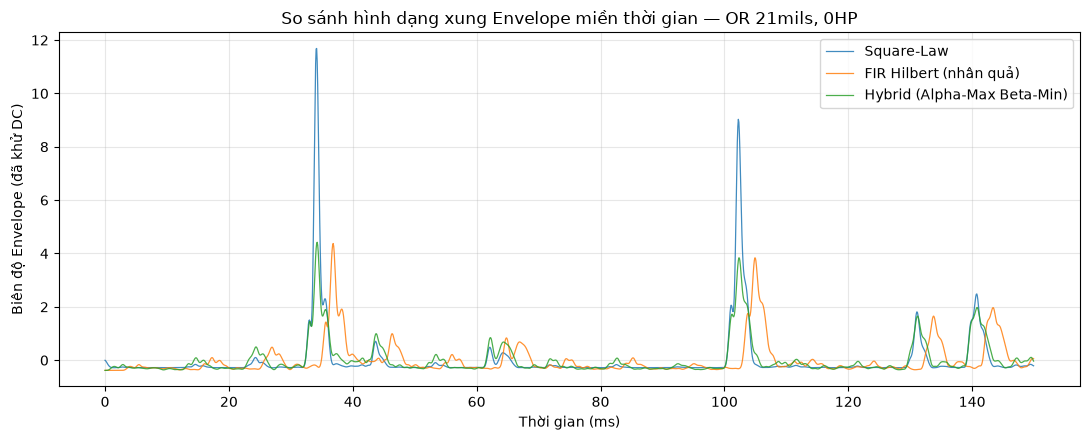

In [ ]:
# --- So sánh 3 phương pháp DSP trong MIỀN THỜI GIAN — đánh giá hình dạng xung ---
N_SECONDS_ENV = 0.15
n_samples_env = int(N_SECONDS_ENV * FS)
t_ms_env = np.arange(n_samples_env) / FS * 1000

fig, ax = plt.subplots(figsize=(11, 4.5))
for name, env in methods.items():
    env_centered = env - env.mean()
    ax.plot(t_ms_env, env_centered[:n_samples_env], linewidth=0.9,
            color=method_colors[name], label=name, alpha=0.85)

ax.set_xlabel("Thời gian (ms)")
ax.set_ylabel("Biên độ Envelope (đã khử DC)")
ax.set_title(f"So sánh hình dạng xung Envelope miền thời gian — {FAULT_LABEL} {DIAMETER_MILS}mils, {LOAD_HP}HP")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_envelope_3_methods_time_domain.png", dpi=150)
plt.show()

In [ ]:
from scipy.stats import kurtosis

print(f"{'Phương pháp':30s} | {'Kurtosis envelope':>18s} | {'Peak-to-floor (dB)':>18s}")
print("-" * 72)
quality_rows = []
for name, env in methods.items():
    env_centered = env - env.mean()
    # Kurtosis của envelope — dùng đúng công thức Nhóm A (features_full.py),
    # đo tính "xung" (impulsiveness): xung càng sắc nét, kurtosis càng cao.
    k = kurtosis(env_centered)

    freqs_m, mag_m = dsp.compute_fft(env_centered, fs=FS)
    mask = freqs_m <= FREQ_MAX_PLOT
    mag_band = mag_m[mask]
    peak = mag_band.max()
    noise_floor = np.median(mag_band)  # median bền hơn mean trước outlier chính là các đỉnh
    peak_to_floor_db = 20 * np.log10(peak / (noise_floor + 1e-12))

    quality_rows.append({"method": name, "envelope_kurtosis": round(float(k), 3),
                          "peak_to_floor_db": round(float(peak_to_floor_db), 2)})
    print(f"{name:30s} | {k:18.3f} | {peak_to_floor_db:18.2f}")

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(TABLES_DIR / "05_envelope_quality_metrics.csv", index=False)

Phương pháp                    |  Kurtosis envelope | Peak-to-floor (dB)
------------------------------------------------------------------------
Square-Law                     |             62.409 |              37.60
FIR Hilbert (nhân quả)         |             13.629 |              45.04
Hybrid (Alpha-Max Beta-Min)    |             13.560 |              45.05


In [ ]:
# Bảng chất lượng đường bao: cả 3 nhánh đều NHÂN QUẢ, cùng lp_cutoff.
files_to_check = [("IR", 21, 0), ("OR", 21, 1), ("B", 21, 2), ("OR", 21, 3)]
agg_rows = []

for label, diam, load in files_to_check:
    fp = pipeline.pick_file(manifest, label=label, load_hp=load, diameter_mils=diam)
    x_c = io_utils.load_de_signal(Path(fp))

    for name, env_fn in [("Square-Law", lambda s: dsp.square_law_envelope(s, FS, BAND_HZ, LP_CUTOFF_HZ)),
                          ("FIR Hilbert", lambda s: dsp.hilbert_envelope_fir(s, FS, BAND_HZ, lp_cutoff=LP_CUTOFF_HZ)),
                          ("Hybrid", lambda s: dsp.hybrid_envelope(s, FS, BAND_HZ))]:
        env = env_fn(x_c) - env_fn(x_c).mean()
        k = kurtosis(env)
        freqs_c, mag_c = dsp.compute_fft(env, fs=FS)
        mask_c = freqs_c <= FREQ_MAX_PLOT
        ptf = 20 * np.log10(mag_c[mask_c].max() / (np.median(mag_c[mask_c]) + 1e-12))
        agg_rows.append({"label": label, "diameter": diam, "load_hp": load,
                          "method": name, "kurtosis": round(k, 2), "peak_to_floor_db": round(ptf, 2)})

agg_df = pd.DataFrame(agg_rows)
agg_df.to_csv(TABLES_DIR / "05_envelope_quality_multi_file.csv", index=False)
print(agg_df.groupby("method")[["kurtosis", "peak_to_floor_db"]].mean().round(2))

             kurtosis  peak_to_floor_db
method                                 
FIR Hilbert      8.01             42.25
Hybrid           7.97             42.24
Square-Law      39.14             37.73
